<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>

# **Random Forests for Classification**


## **Introduction**

Bagging and Random Forest are both ensemble methods. An ensemble combines predictions from many models to make one final prediction.

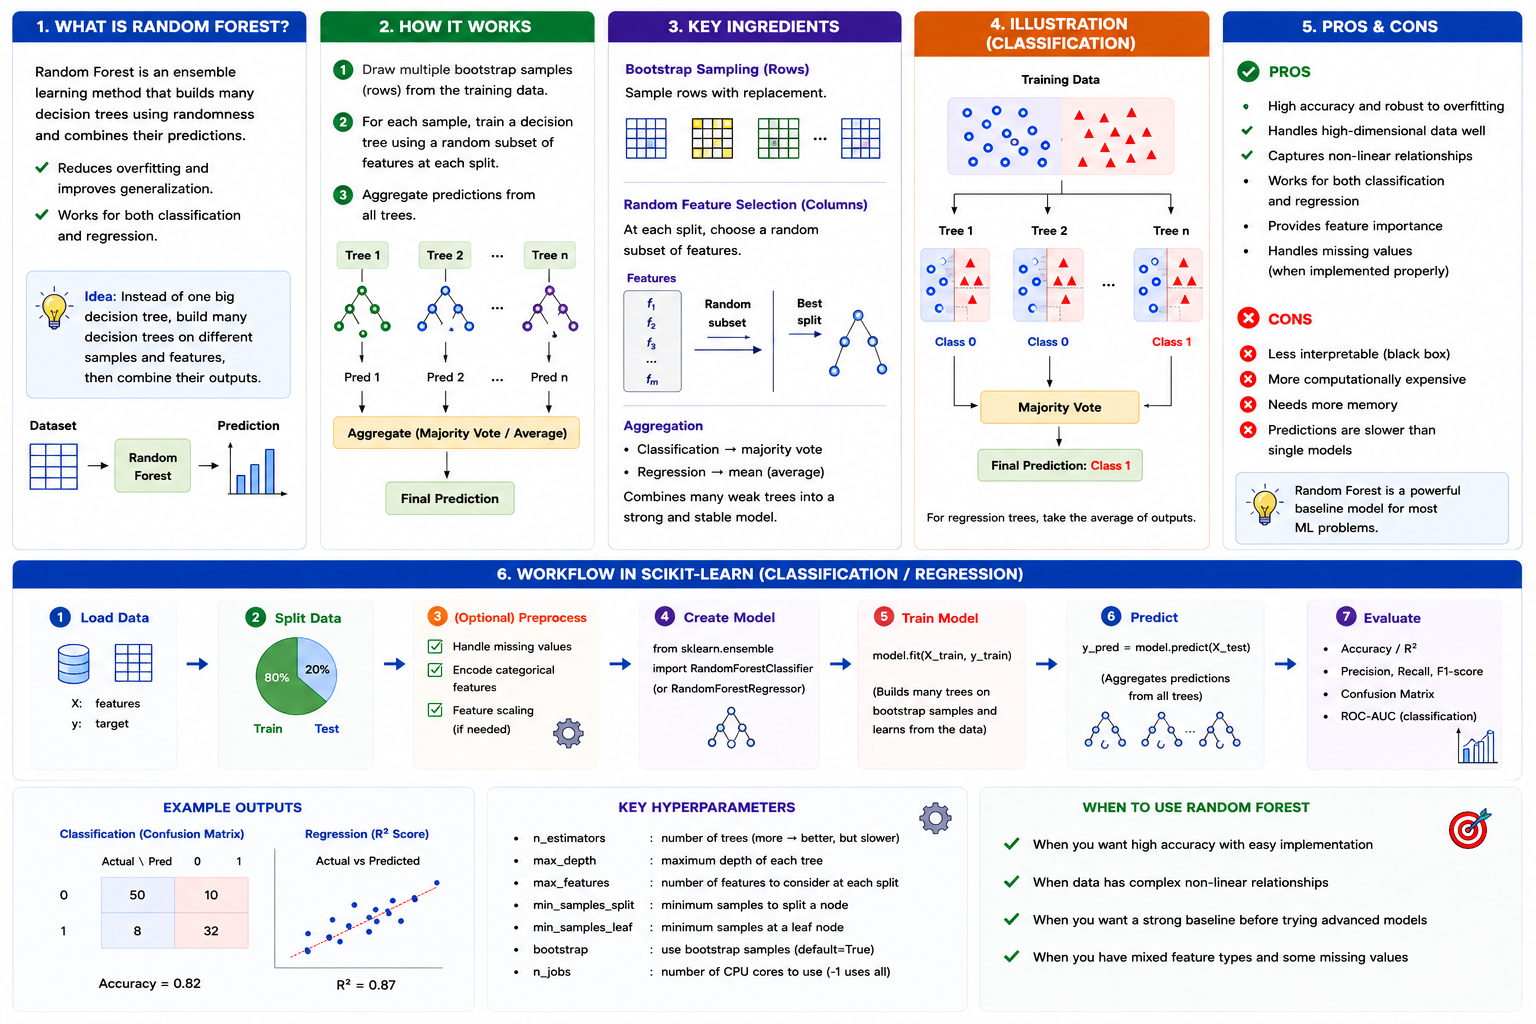
In **Bagging (bootstrap aggregation)**, each decision tree is trained on a different bootstrap sample of the training data. A bootstrap sample is created by randomly selecting rows with replacement. Each tree can still use all features when choosing splits.

**Random Forest** adds one more layer of randomness. Like Bagging, each tree is trained on a bootstrap sample. However, at each split, the tree only considers a random subset of features. This makes the trees more different from each other, so their errors are less correlated. When the trees are combined, these random errors can cancel out and reduce overfitting.

For classification, Random Forest usually combines tree predictions by majority vote:

$$
\hat{y} = \text{mode}(h_1(x), h_2(x), ..., h_B(x))
$$

Here, $h_b(x)$ is the prediction from tree $b$, and $B$ is the total number of trees.

For regression, the final prediction is usually the average of all tree predictions:

$$
\hat{y} = \frac{1}{B}\sum_{b=1}^{B} h_b(x)
$$

Each tree still uses the same split logic as a decision tree. For classification, each split tries to reduce impurity, such as Gini impurity or entropy:

$$
Cost = \frac{n_{left}}{n}I_{left} + \frac{n_{right}}{n}I_{right}
$$

Here, $I$ is the impurity of a node. Random Forest does not use a new cost function for the whole forest. Its main improvement comes from combining many trees that are trained with bootstrap samples and random feature subsets.

In this lab, we will compare Bagging and Random Forest, examine tree correlation, train Random Forest classifiers, and use GridSearchCV to tune hyperparameters.


## **Objectives**

A telecommunications company wants to understand why some customers are leaving its landline service for cable competitors. We will use a telecommunications dataset to predict **customer churn**.

* Understand the difference between Bagging and Random Forest
* Explain why Random Forest trees are usually less correlated than Bagging trees
* Train and evaluate Random Forest classifiers
* Tune important Random Forest hyperparameters


## **Workflow**
### **Setup**
First, import the required libraries.


In [330]:
import random
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import scipy.optimize as opt
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn import metrics, preprocessing
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
from tqdm import tqdm

rs = 0


Ignore warning messages so the notebook output is easier to read.


In [ ]:
import warnings

warnings.filterwarnings("ignore")

This function calculates training and testing accuracy for a fitted model.


In [ ]:
def get_accuracy(X_train, X_test, y_train, y_test, model):
    return {
        "test Accuracy": metrics.accuracy_score(y_test, model.predict(X_test)),
        "trian Accuracy": metrics.accuracy_score(
            y_train, model.predict(X_train)
        ),
    }

This function calculates the average correlation between tree predictions and displays the pairwise correlation between trees.


In [ ]:
def get_correlation(X_test, y_test, models):
    # This function calculates the average correlation between tree predictions
    n_estimators = len(models.estimators_)
    prediction = np.zeros((y_test.shape[0], n_estimators))
    predictions = pd.DataFrame(
        {"estimator " + str(n + 1): [] for n in range(n_estimators)}
    )

    for key, model in zip(predictions.keys(), models.estimators_):
        predictions[key] = model.predict(X_test.to_numpy())

    corr = predictions.corr()
    print(
        "Average correlation between tree predictions: ",
        corr.mean().mean() - 1 / n_estimators,
    )
    return corr

### **Customer Data Example**

#### **About the dataset**

We will use a telecommunications dataset to predict customer churn. Each row represents one customer. The data is easy to understand, and it can help us find useful business insights.

Customer churn means that a customer leaves the company. Because keeping existing customers is usually less expensive than getting new ones, the goal is to understand which customers are likely to stay or leave.

This dataset provides customer information that can help the company understand churn behavior and build focused customer retention programs.

The dataset includes information about:

*   Customers who left within the last month. This target column is called `Churn`.
*   Services each customer has signed up for, such as phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies.
*   Customer account information, such as how long they have been a customer, contract type, payment method, paperless billing, monthly charges, and total charges.
*   Customer demographic information, such as gender, age range, and whether they have partners or dependents.

The same customer churn dataset is used for the tree-based methods in notebooks 3.5.1 to 3.5.4.

Load the data from the CSV file.


In [ ]:
churn_df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/ChurnData.csv"
)

churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,...,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,...,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,...,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,...,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,...,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,...,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


#### **Data Preprocessing and Feature Selection**


Select the modeling features and convert the target variable to an integer type, which is required by `sklearn` classifiers.


In [ ]:
churn_df = churn_df[
    [
        "tenure",
        "age",
        "address",
        "income",
        "ed",
        "employ",
        "equip",
        "callcard",
        "wireless",
        "churn",
    ]
]
churn_df["churn"] = churn_df["churn"].astype("int")
churn_df.head()

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0


#### **Bootstrap Sampling**

Bootstrap sampling means drawing rows from a dataset **with replacement**. Because sampling is done with replacement, the same row can appear more than once in a bootstrap sample.

Scikit-learn can perform bootstrap sampling inside Bagging and Random Forest models, but it is useful to see how the process works directly. We will use the `resample` function for this example.


In [336]:
from sklearn.utils import resample

Start with the first five rows of the data.


In [337]:
churn_df[0:5]

,tenure,age,address,income,ed,employ,equip,callcard,wireless,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,1
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,1
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,0


Now create a bootstrap sample with `resample`. The new sample has the same number of rows, but some original rows may appear more than once.


In [338]:
for n in range(5):

    print(resample(churn_df[0:5]))

   tenure   age  address  income   ed  employ  equip  callcard  wireless  \
0    11.0  33.0      7.0   136.0  5.0     5.0    0.0       1.0       1.0   
3    38.0  35.0      5.0    76.0  2.0    10.0    1.0       1.0       1.0   
1    33.0  33.0     12.0    33.0  2.0     0.0    0.0       0.0       0.0   
1    33.0  33.0     12.0    33.0  2.0     0.0    0.0       0.0       0.0   
2    23.0  30.0      9.0    30.0  1.0     2.0    0.0       0.0       0.0   

   churn  
0      1  
3      0  
1      1  
1      1  
2      0  
   tenure   age  address  income   ed  employ  equip  callcard  wireless  \
4     7.0  35.0     14.0    80.0  2.0    15.0    0.0       1.0       0.0   
1    33.0  33.0     12.0    33.0  2.0     0.0    0.0       0.0       0.0   
4     7.0  35.0     14.0    80.0  2.0    15.0    0.0       1.0       0.0   
0    11.0  33.0      7.0   136.0  5.0     5.0    0.0       1.0       1.0   
3    38.0  35.0      5.0    76.0  2.0    10.0    1.0       1.0       1.0   

   churn  
4      0 

#### **Select Variables at Random**


Like Bagging, Random Forest trains each tree on a bootstrap sample from the training data. The extra step in Random Forest is feature sampling: at each split, the tree considers only `m` randomly selected features out of all `M` features.

The example below shows how this feature sampling works.


In [ ]:
X = churn_df[["tenure", "age", "address", "income", "ed", "employ", "equip"]]

There are 7 input features.


In [ ]:
M = X.shape[1]
M

7

Let `m=3`. We will randomly choose 3 features from the bootstrap sample above.


In [ ]:
m = 3

First, list the feature indexes.


In [ ]:
feature_index = range(M)
feature_index

range(0, 7)

Use sampling to randomly select feature indexes.


In [ ]:
import random

random.sample(feature_index, m)

[2, 3, 0]

Now use the selected indexes to keep only a random subset of features from the bootstrap sample.


In [ ]:
for n in range(5):

    print("sample {}".format(n))
    print(resample(X[0:5]).iloc[:, random.sample(feature_index, m)])

sample 0
   tenure  equip   ed
2    23.0    0.0  1.0
4     7.0    0.0  2.0
0    11.0    0.0  5.0
0    11.0    0.0  5.0
0    11.0    0.0  5.0
sample 1
   income  equip  address
4    80.0    0.0     14.0
2    30.0    0.0      9.0
1    33.0    0.0     12.0
2    30.0    0.0      9.0
1    33.0    0.0     12.0
sample 2
    age  equip  tenure
1  33.0    0.0    33.0
4  35.0    0.0     7.0
4  35.0    0.0     7.0
4  35.0    0.0     7.0
4  35.0    0.0     7.0
sample 3
   employ  tenure  income
4    15.0     7.0    80.0
3    10.0    38.0    76.0
1     0.0    33.0    33.0
4    15.0     7.0    80.0
0     5.0    11.0   136.0
sample 4
   address  tenure  employ
2      9.0    23.0     2.0
2      9.0    23.0     2.0
0      7.0    11.0     5.0
1     12.0    33.0     0.0
3      5.0    38.0    10.0


In a Random Forest, each tree uses this kind of random row and feature sampling while it learns its splits.


#### **Train/Test Dataset**


Define `X` and `y` for the churn dataset.


In [ ]:
y = churn_df["churn"]
y.head()

0    1
1    1
2    0
3    0
4    0
Name: churn, dtype: int64

Split the dataset into training and testing sets.


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=1
)
print("Train set", X_train.shape, y_train.shape)
print("Test set", X_test.shape, y_test.shape)

Train set (140, 7) (140,)
Test set (60, 7) (60,)


#### **Bagging Review**


In [347]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

Bagging is useful for models that can overfit, such as decision trees. A single decision tree may perform very well on the training data but generalize poorly to new data. Bagging reduces this problem by training many trees on different bootstrap samples and combining their predictions.

Here, we create a `BaggingClassifier` using a decision tree as the base estimator.


In [ ]:
n_estimators = 20
Bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy", max_depth=4, random_state=2
    ),
    n_estimators=n_estimators,
    random_state=0,
    bootstrap=True,
)

Fit the Bagging model.


In [ ]:
Bag.fit(X_train, y_train)

,estimator,DecisionTreeC...andom_state=2)
,n_estimators,20
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,0
,verbose,0


Use `predict` to combine tree predictions by voting.


In [350]:
Bag.predict(X_test).shape

(60,)

The Bagging model has high training accuracy and much better test accuracy than a single overfit tree.


In [ ]:
print(get_accuracy(X_train, X_test, y_train, y_test, Bag))

{'test Accuracy': 0.75, 'trian Accuracy': 0.9214285714285714}


Each tree in Bagging can still be similar to the others. We can check this by plotting the correlation between tree predictions.


In [ ]:
get_correlation(X_test, y_test, Bag).style.background_gradient(cmap="coolwarm")

Average correlation between tree predictions:  0.20473247659785898


,estimator 1,estimator 2,estimator 3,estimator 4,estimator 5,estimator 6,estimator 7,estimator 8,estimator 9,estimator 10,estimator 11,estimator 12,estimator 13,estimator 14,estimator 15,estimator 16,estimator 17,estimator 18,estimator 19,estimator 20
estimator 1,1.000000,0.101278,0.151710,0.107204,0.151710,0.127735,0.095130,0.029935,0.274856,0.150414,0.166478,-0.273160,0.732601,0.196550,0.005070,0.493525,0.044845,0.420467,0.380521,0.209836
estimator 2,0.101278,1.000000,0.315637,0.498682,0.468365,0.533859,0.183556,0.438974,0.060910,0.255400,0.513956,-0.007270,0.180382,0.001920,0.133056,-0.120012,0.571092,0.232348,-0.036711,0.354161
estimator 3,0.151710,0.315637,1.000000,0.194288,0.278846,0.154585,0.138675,0.507777,0.388766,0.482382,0.034669,-0.027462,0.124484,0.297398,0.539573,0.039421,0.196116,0.406203,0.034669,0.194960
estimator 4,0.107204,0.498682,0.194288,1.000000,0.320998,0.603412,0.121829,0.482686,-0.040079,0.365994,0.304572,0.162849,0.247503,0.084435,0.201299,-0.082251,0.416373,-0.011152,0.030457,0.246580
estimator 5,0.151710,0.468365,0.278846,0.320998,1.000000,0.154585,0.450694,0.626787,0.269756,0.482382,0.242681,-0.027462,0.222761,-0.029014,0.206959,0.039421,0.686406,0.188594,0.138675,0.396644
estimator 6,0.127735,0.533859,0.154585,0.603412,0.154585,1.000000,0.202678,0.337728,0.163791,0.176254,0.506695,0.115392,0.225027,0.128542,0.075619,-0.039610,0.250801,0.128542,-0.177343,0.126504
estimator 7,0.095130,0.183556,0.138675,0.121829,0.450694,0.202678,1.000000,0.228852,0.400491,0.347851,0.400000,0.396059,0.259851,0.261533,0.293151,-0.071067,0.235702,0.183073,0.325000,0.169675
estimator 8,0.029935,0.438974,0.507777,0.482686,0.626787,0.337728,0.228852,1.000000,0.312602,0.741785,0.314671,0.118963,0.075686,0.207987,0.506210,0.012198,0.633805,0.118208,-0.028606,0.334219
estimator 9,0.274856,0.060910,0.388766,-0.040079,0.269756,0.163791,0.400491,0.312602,1.000000,0.416123,0.228852,0.005665,0.237869,0.297765,0.323243,0.093517,0.229249,0.297765,0.143032,0.334219
estimator 10,0.150414,0.255400,0.482382,0.365994,0.482382,0.176254,0.347851,0.741785,0.416123,1.000000,0.347851,0.313112,0.298807,0.215030,0.640490,-0.044947,0.447214,0.314275,0.063246,0.383257


High correlation between trees can reduce ensemble performance. Random Forest reduces this correlation by sampling features at each split.


#### **Random Forest**


A Random Forest is an ensemble of decision trees. Each tree is trained on a random sample of rows and considers a random subset of features at each split. This makes the trees more different from each other and often improves performance compared with Bagging.

Two important Random Forest hyperparameters are the number of trees and the number of features considered at each split. First, import `RandomForestClassifier`.


In [353]:
from sklearn.ensemble import RandomForestClassifier

Increasing the number of trees often improves results, but the improvement usually becomes smaller after a certain point. In this example, we use the default number of trees, which is 100.


In [ ]:
n_estimators = 20

`max_features` controls how many features are considered when looking for the best split at each node. If the dataset has `M` total features, then `max_features` defines the value of `m`.


In [ ]:
M_features = X.shape[1]

A common default for classification is to set `m` to the square root of `M`.


$m= floor(\sqrt{M}) $


In [ ]:
max_features = round(np.sqrt(M_features)) - 1
max_features

2

In [357]:
y_test

10     0
174    1
27     0
5      0
143    0
149    1
99     0
54     1
192    0
197    0
98     0
134    1
83     1
108    0
147    0
157    1
16     0
120    1
191    0
26     0
124    0
88     1
64     0
28     0
47     0
76     0
160    1
90     1
11     0
73     0
196    0
187    1
91     0
110    0
148    0
2      0
58     1
137    0
9      0
38     0
65     0
119    0
156    0
84     1
81     0
185    0
182    0
128    1
117    1
96     1
3      0
190    0
194    0
61     0
94     0
170    0
163    1
31     0
78     0
30     0
Name: churn, dtype: int64

Use `floor` to make sure `m` is an integer.


Create the Random Forest model.


In [ ]:
model = RandomForestClassifier(
    max_features=max_features, n_estimators=n_estimators, random_state=0
)

Train the Random Forest model.


In [ ]:
model.fit(X_train, y_train)

,n_estimators,20
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,2
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Calculate the training and testing accuracy. In this example, Random Forest performs better than Bagging.


In [360]:
print(get_accuracy(X_train, X_test, y_train, y_test, model))

{'test Accuracy': 0.75, 'trian Accuracy': 1.0}


The Random Forest trees are less correlated with each other than the Bagging trees.


In [ ]:
get_correlation(X_test, y_test, model).style.background_gradient(
    cmap="coolwarm"
)

Average correlation between tree predictions:  0.22152309255523145


,estimator 1,estimator 2,estimator 3,estimator 4,estimator 5,estimator 6,estimator 7,estimator 8,estimator 9,estimator 10,estimator 11,estimator 12,estimator 13,estimator 14,estimator 15,estimator 16,estimator 17,estimator 18,estimator 19,estimator 20
estimator 1,1.000000,0.062500,0.112872,0.174078,0.088638,0.033710,0.062500,0.261116,0.180937,-0.065795,0.098693,0.337100,0.245058,0.062500,0.213201,0.039031,0.453052,0.189642,0.540862,-0.044607
estimator 2,0.062500,1.000000,0.201981,0.348155,0.323268,0.134840,-0.022727,0.348155,0.180937,0.427669,0.180937,0.134840,0.245058,0.147727,0.213201,0.206308,0.373101,0.268659,0.039031,0.373585
estimator 3,0.112872,0.201981,1.000000,0.045502,0.397958,0.387699,0.380199,0.227508,0.154782,0.326762,0.154782,0.176227,0.152641,0.112872,0.529414,0.527603,0.362231,0.421344,0.177811,0.352707
estimator 4,0.174078,0.348155,0.045502,1.000000,0.199681,0.258199,0.261116,0.200000,0.461957,0.293972,0.209980,0.154919,0.279553,0.348155,0.000000,-0.021354,0.244949,0.221917,0.149478,0.064062
estimator 5,0.088638,0.323268,0.397958,0.199681,1.000000,0.309344,0.323268,0.199681,0.332078,0.256606,0.105661,0.123738,0.282297,0.088638,0.489116,0.289099,0.269014,0.456822,0.212347,0.289099
estimator 6,0.033710,0.134840,0.387699,0.258199,0.309344,1.000000,0.235970,0.051640,0.390360,0.195180,0.195180,-0.080000,0.309344,0.235970,0.252982,0.115786,0.063246,0.234404,0.016541,0.314275
estimator 7,0.062500,-0.022727,0.380199,0.261116,0.323268,0.235970,1.000000,0.087039,0.180937,0.180937,0.098693,0.235970,0.245058,0.232955,0.293151,0.373585,0.053300,0.347677,0.373585,0.206308
estimator 8,0.261116,0.348155,0.227508,0.200000,0.199681,0.051640,0.087039,1.000000,0.125988,0.293972,0.209980,0.361478,0.199681,-0.000000,0.326599,0.234895,0.326599,0.221917,0.234895,0.234895
estimator 9,0.180937,0.180937,0.154782,0.461957,0.332078,0.390360,0.180937,0.125988,1.000000,0.206349,0.206349,0.195180,0.483022,0.427669,0.308607,0.072640,0.231455,0.205879,0.314772,0.153351
estimator 10,-0.065795,0.427669,0.326762,0.293972,0.256606,0.195180,0.180937,0.293972,0.206349,1.000000,0.126984,0.097590,0.105661,0.180937,0.385758,0.395483,0.462910,0.205879,0.072640,0.153351


#### **Evaluation**

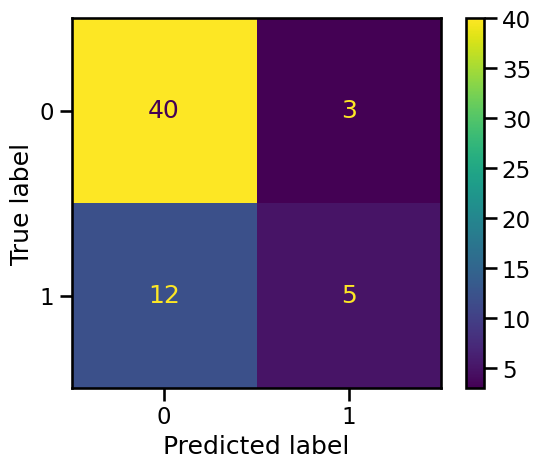

In [ ]:
y_pred = model.predict(X_test)

sns.set_context("talk")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=model.classes_
)
disp.plot()
plt.show()

Plot the ROC-AUC and precision-recall curves using the predicted probability for the positive class.


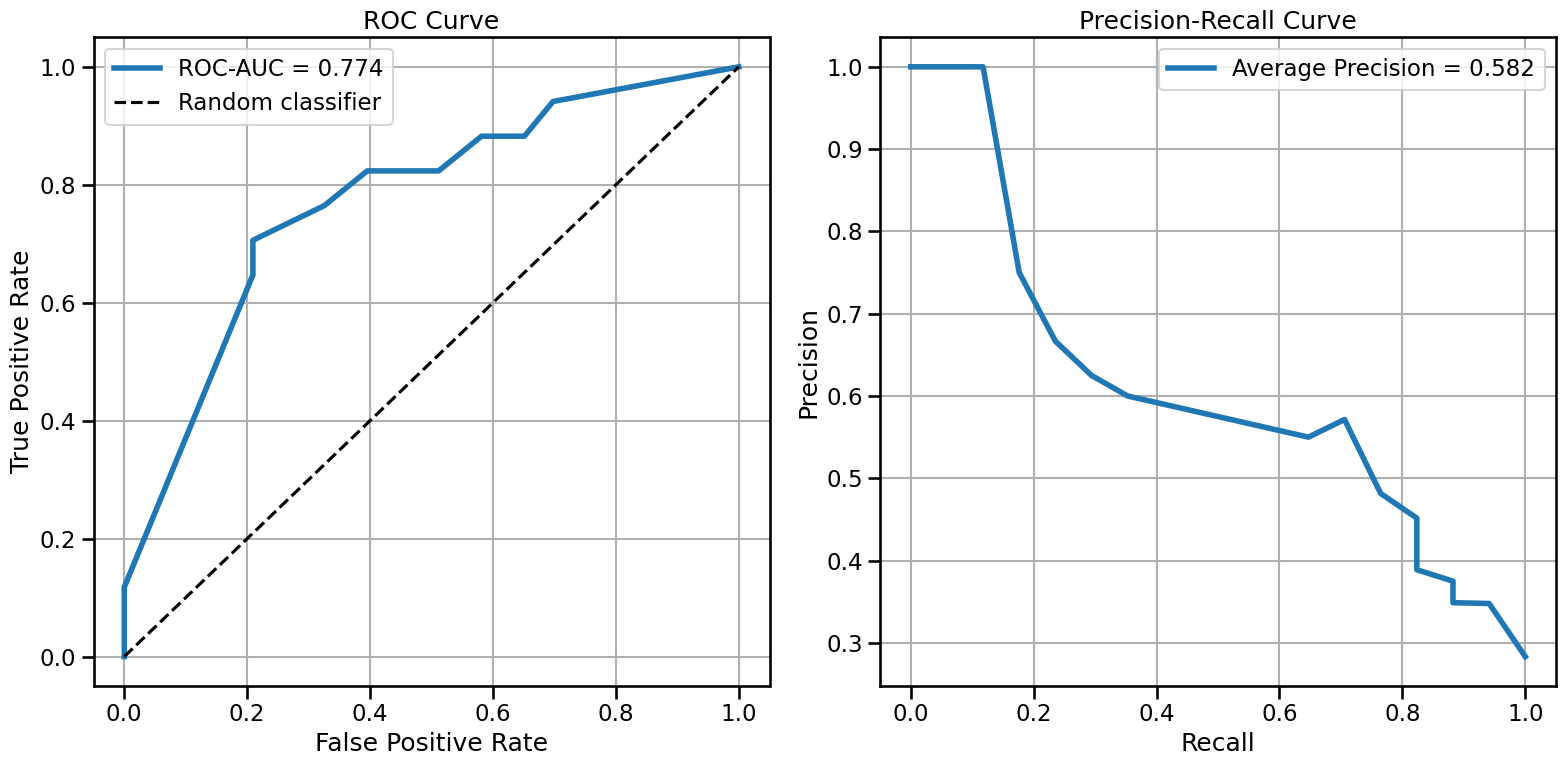

In [ ]:
sns.set_context("talk")

# Get predicted probabilities for class 1.
y_score = model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = roc_auc_score(y_test, y_score)
axes[0].plot(fpr, tpr, linewidth=4, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot(
    [0, 1], [0, 1], linestyle="--", color="black", label="Random classifier"
)
axes[0].set(
    title="ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate"
)
axes[0].legend()
axes[0].grid(True)

# Precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, y_score)
avg_precision = metrics.average_precision_score(y_test, y_score)
axes[1].plot(
    recall,
    precision,
    linewidth=4,
    label=f"Average Precision = {avg_precision:.3f}",
)
axes[1].set(title="Precision-Recall Curve", xlabel="Recall", ylabel="Precision")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Findings:**

The churn model predicts most non-churn customers correctly, but it misses several customers who actually churned. The ROC-AUC is about `0.774`, which means the model separates churn and non-churn customers better than random guessing, but there is still room to improve recall for churn customers.


#### **Feature Importance**

The feature-importance plot shows which churn features the Random Forest used most often to improve its splits.


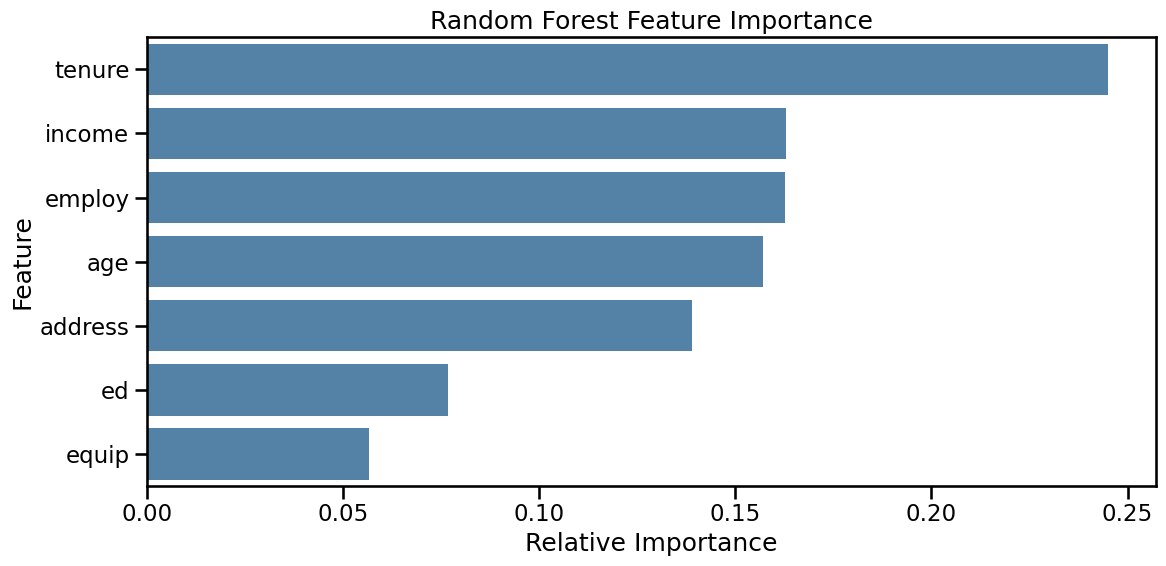

In [ ]:
feature_names = X_train.columns

feature_imp = pd.Series(
    model.feature_importances_, index=feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=ax, color="steelblue")
ax.set(
    title="Random Forest Feature Importance",
    xlabel="Relative Importance",
    ylabel="Feature",
)

plt.tight_layout()
plt.show()

**Findings:**

`tenure` is the most important feature in the churn model. `income`, `employ`, and `age` also contribute meaningfully. `equip` has the lowest importance, so it has less influence on the model's splits in this example.


### **Cancer Data Example**

This example uses a public cell sample dataset from the UCI Machine Learning Repository. Each row represents one cell sample, and each feature describes a cell characteristic. The target variable, `Class`, identifies whether the sample is benign or malignant.

The dataset fields are:

| Field name  | Description                 |
| ----------- | --------------------------- |
| ID          | Sample ID                   |
| Clump       | Clump thickness             |
| UnifSize    | Uniformity of cell size     |
| UnifShape   | Uniformity of cell shape    |
| MargAdh     | Marginal adhesion           |
| SingEpiSize | Single epithelial cell size |
| BareNuc     | Bare nuclei                 |
| BlandChrom  | Bland chromatin             |
| NormNucl    | Normal nucleoli             |
| Mit         | Mitoses                     |
| Class       | Benign or malignant         |

Load the dataset below.


In [ ]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/cell_samples.csv"
)

df.head()

,ID,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


Remove rows that have a `?` value in the `BareNuc` column.


In [ ]:
df = df[pd.to_numeric(df["BareNuc"], errors="coerce").notnull()]

Select the input features.


In [ ]:
X = df[
    [
        "Clump",
        "UnifSize",
        "UnifShape",
        "MargAdh",
        "SingEpiSize",
        "BareNuc",
        "BlandChrom",
        "NormNucl",
        "Mit",
    ]
]

X.head()

,Clump,UnifSize,UnifShape,MargAdh,SingEpiSize,BareNuc,BlandChrom,NormNucl,Mit
0,5,1,1,1,2,1,3,1,1
1,5,4,4,5,7,10,3,2,1
2,3,1,1,1,2,2,3,1,1
3,6,8,8,1,3,4,3,7,1
4,4,1,1,3,2,1,3,1,1


Select the class labels.


In [ ]:
y = df["Class"]
y.head()

0    2
1    2
2    2
3    2
4    2
Name: Class, dtype: int64

Split the data into training and testing sets.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=4
)
print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (546, 9) (546,)
Test set: (137, 9) (137,)


Use `GridSearchCV` to search over selected Random Forest parameter values. Because this is a classification task, we use `StratifiedKFold` for cross-validation. It keeps the class proportions similar in each fold, and `shuffle=True` randomizes the data before the folds are created.


In [370]:
from sklearn.model_selection import GridSearchCV

Create a `RandomForestClassifier` object and display its parameters with `get_params()`.


In [371]:
model = RandomForestClassifier()
model.get_params().keys()

dict_keys(['bootstrap', 'ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'max_samples', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'n_estimators', 'n_jobs', 'oob_score', 'random_state', 'verbose', 'warm_start'])

Use GridSearchCV to search over selected parameter values. Many Random Forest parameters are similar to decision tree parameters. Here, we tune `max_depth`, `max_features`, and `n_estimators`.


In [ ]:
param_grid = {
    "n_estimators": [2 * n + 1 for n in range(20)],
    "max_depth": [2 * n + 1 for n in range(10)],
    "max_features": [None, "sqrt", "log2"],
}

Create the GridSearchCV object and fit it to the training data.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)

search = GridSearchCV(
    estimator=model, param_grid=param_grid, scoring="accuracy", cv=cv
)
search.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [1, 3, ...], 'max_features': [None, 'sqrt', ...], 'n_estimators': [1, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,31


The best cross-validation accuracy from the searched parameters is about 98%.


In [374]:
search.best_score_

0.9816680567139283

The best parameter values are shown below.


In [375]:
search.best_params_

{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 31}

Evaluate the best model on the test data.


In [ ]:
print(get_accuracy(X_train, X_test, y_train, y_test, search.best_estimator_))

{'test Accuracy': 0.9562043795620438, 'trian Accuracy': 0.9908424908424909}


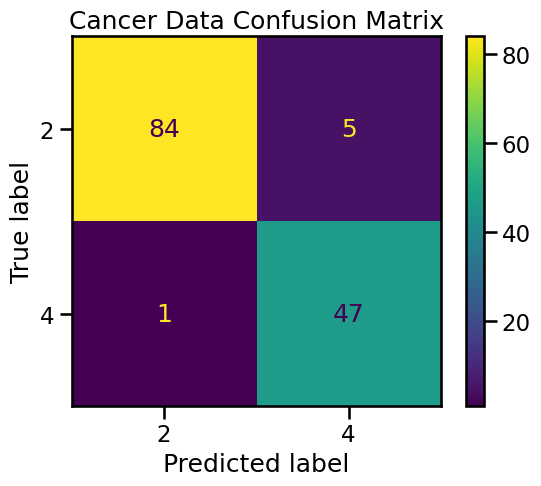

In [ ]:
best_rf = search.best_estimator_
y_pred = best_rf.predict(X_test)

sns.set_context("talk")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=best_rf.classes_
)
disp.plot()
plt.title("Cancer Data Confusion Matrix")
plt.show()

Plot the ROC-AUC and precision-recall curves using the predicted probability for the malignant class.


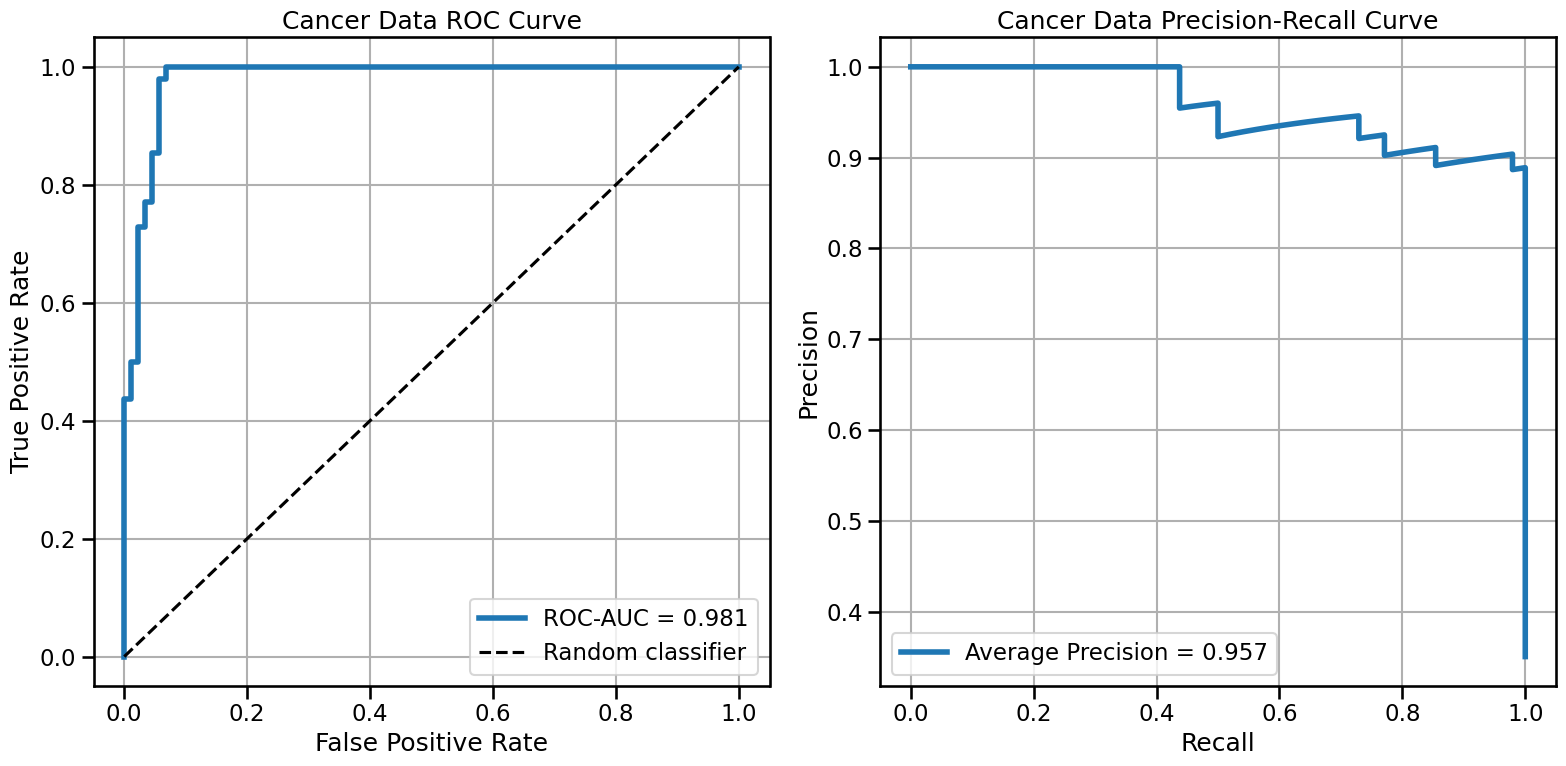

In [ ]:
# In this dataset, class 4 represents malignant samples.
positive_class = 4
y_score = best_rf.predict_proba(X_test)[
    :, list(best_rf.classes_).index(positive_class)
]
y_test_binary = (y_test == positive_class).astype(int)

fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

# ROC curve
fpr, tpr, _ = roc_curve(y_test_binary, y_score)
roc_auc = roc_auc_score(y_test_binary, y_score)
axes[0].plot(fpr, tpr, linewidth=4, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot(
    [0, 1], [0, 1], linestyle="--", color="black", label="Random classifier"
)
axes[0].set(
    title="Cancer Data ROC Curve",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
)
axes[0].legend()
axes[0].grid(True)

# Precision-recall curve
precision, recall, _ = precision_recall_curve(y_test_binary, y_score)
avg_precision = metrics.average_precision_score(y_test_binary, y_score)
axes[1].plot(
    recall,
    precision,
    linewidth=4,
    label=f"Average Precision = {avg_precision:.3f}",
)
axes[1].set(
    title="Cancer Data Precision-Recall Curve",
    xlabel="Recall",
    ylabel="Precision",
)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Findings:**

The cancer model performs very well on the test data. The confusion matrix shows that most benign and malignant samples are classified correctly, with only a small number of mistakes. The ROC-AUC is about `0.981`, and the precision-recall curve also stays high, showing strong separation between benign and malignant samples.


#### **Feature Importance**

Plot the most important cell features used by the best Random Forest model.


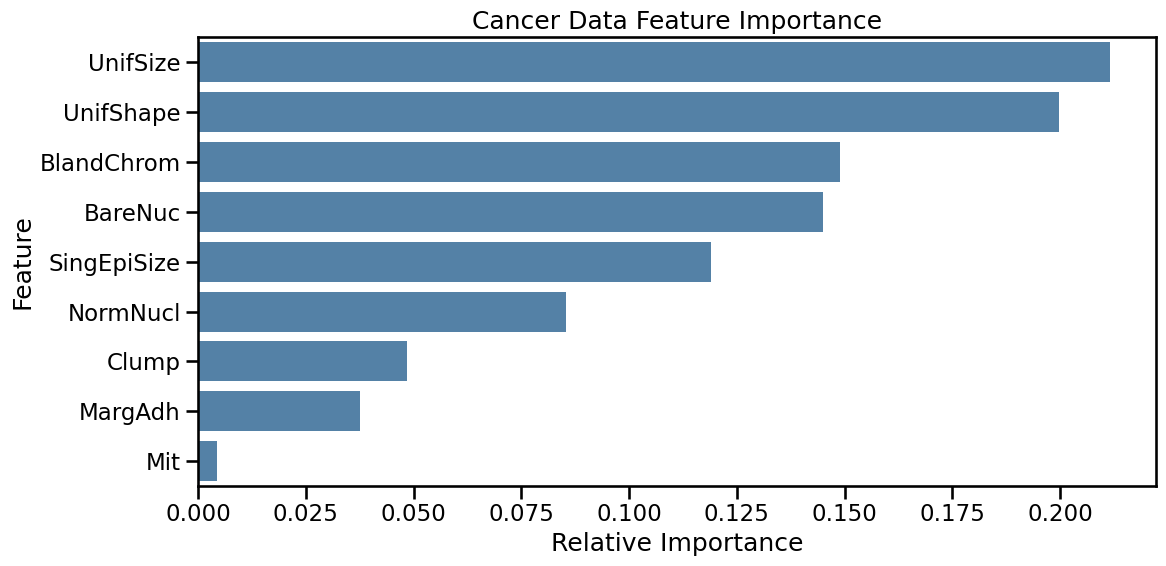

In [ ]:
feature_imp = pd.Series(
    best_rf.feature_importances_, index=X_train.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=ax, color="steelblue")
ax.set(
    title="Cancer Data Feature Importance",
    xlabel="Relative Importance",
    ylabel="Feature",
)

plt.tight_layout()
plt.show()

**Findings:**

`UnifSize` is the most important feature for the cancer model, followed by `BareNuc`. Features such as `BlandChrom`, `SingEpiSize`, `NormNucl`, and `UnifShape` also help the model, while `Mit` contributes very little in this fitted model.


In [380]:
from sklearn.metrics import classification_report

preds = search.best_estimator_.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           2       0.99      0.94      0.97        89
           4       0.90      0.98      0.94        48

    accuracy                           0.96       137
   macro avg       0.95      0.96      0.95       137
weighted avg       0.96      0.96      0.96       137



#### **Evaluation**

Evaluate the best Random Forest model from GridSearchCV using a confusion matrix.


### **Exercise: Course of Treatment Data**


Imagine you are a medical researcher studying patients with the same illness. Each patient responded well to one of five medications: Drug A, Drug B, Drug C, Drug X, or Drug Y.

Your goal is to build a model that predicts which drug may be appropriate for a future patient. The features are `Age`, `Sex`, `Blood Pressure`, and `Cholesterol`. The target variable is the drug that worked for each patient.

This is a multiclass classification problem because the target has more than two possible drug classes.


In [ ]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv",
    delimiter=",",
)
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


Create `X` and `y` for the drug dataset.


In [ ]:
X = df[["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]].values
X[0:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [383]:
y = df["Drug"]
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: object

Use `LabelEncoder` to convert categorical features into numeric values.


In [ ]:
from sklearn import preprocessing

le_sex = preprocessing.LabelEncoder()
le_sex.fit(["F", "M"])
X[:, 1] = le_sex.transform(X[:, 1])


le_BP = preprocessing.LabelEncoder()
le_BP.fit(["LOW", "NORMAL", "HIGH"])
X[:, 2] = le_BP.transform(X[:, 2])


le_Chol = preprocessing.LabelEncoder()
le_Chol.fit(["NORMAL", "HIGH"])
X[:, 3] = le_Chol.transform(X[:, 3])

X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

Split the data into training and testing sets using an 80/20 split.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=4
)
print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (160, 5) (160,)
Test set: (40, 5) (40,)


Use GridSearchCV to search over selected parameter values.


In [ ]:
param_grid = {
    "n_estimators": [2 * n + 1 for n in range(20)],
    "max_depth": [2 * n + 1 for n in range(10)],
    "max_features": [None, "sqrt", "log2"],
}

Create a `RandomForestClassifier` object called `model`.


In [387]:
model = RandomForestClassifier()

Create a `StratifiedKFold` object for cross-validation. Then create a `GridSearchCV` object called `search` using `model`, `param_grid`, `accuracy` scoring, and the stratified cross-validation object. Finally, fit `search` on `X_train` and `y_train`.


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)

search = GridSearchCV(
    estimator=model, param_grid=param_grid, scoring="accuracy", cv=cv
)
search.fit(X_train, y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'max_depth': [1, 3, ...], 'max_features': [None, 'sqrt', ...], 'n_estimators': [1, 3, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,11


Find the accuracy of the best model from GridSearchCV.


In [389]:
search.best_score_

1.0

Find the best parameter values.


In [390]:
search.best_params_

{'max_depth': 17, 'max_features': 'log2', 'n_estimators': 11}

Evaluate the best model on the test data.


In [ ]:
print(get_accuracy(X_train, X_test, y_train, y_test, search.best_estimator_))

{'test Accuracy': 1.0, 'trian Accuracy': 1.0}


In [392]:
preds = search.best_estimator_.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         5
       drugB       1.00      1.00      1.00         3
       drugC       1.00      1.00      1.00         3
       drugX       1.00      1.00      1.00        11
       drugY       1.00      1.00      1.00        18

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



#### **Evaluation**

Evaluate the best Random Forest model from GridSearchCV using a confusion matrix.


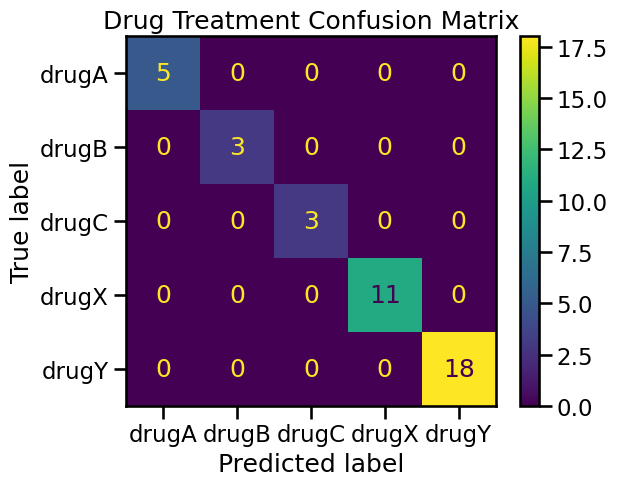

In [ ]:
drug_rf = search.best_estimator_
y_pred = drug_rf.predict(X_test)

sns.set_context("talk")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=drug_rf.classes_
)
disp.plot()
plt.title("Drug Treatment Confusion Matrix")
plt.show()

Plot one-vs-rest ROC-AUC and precision-recall curves for each drug class.


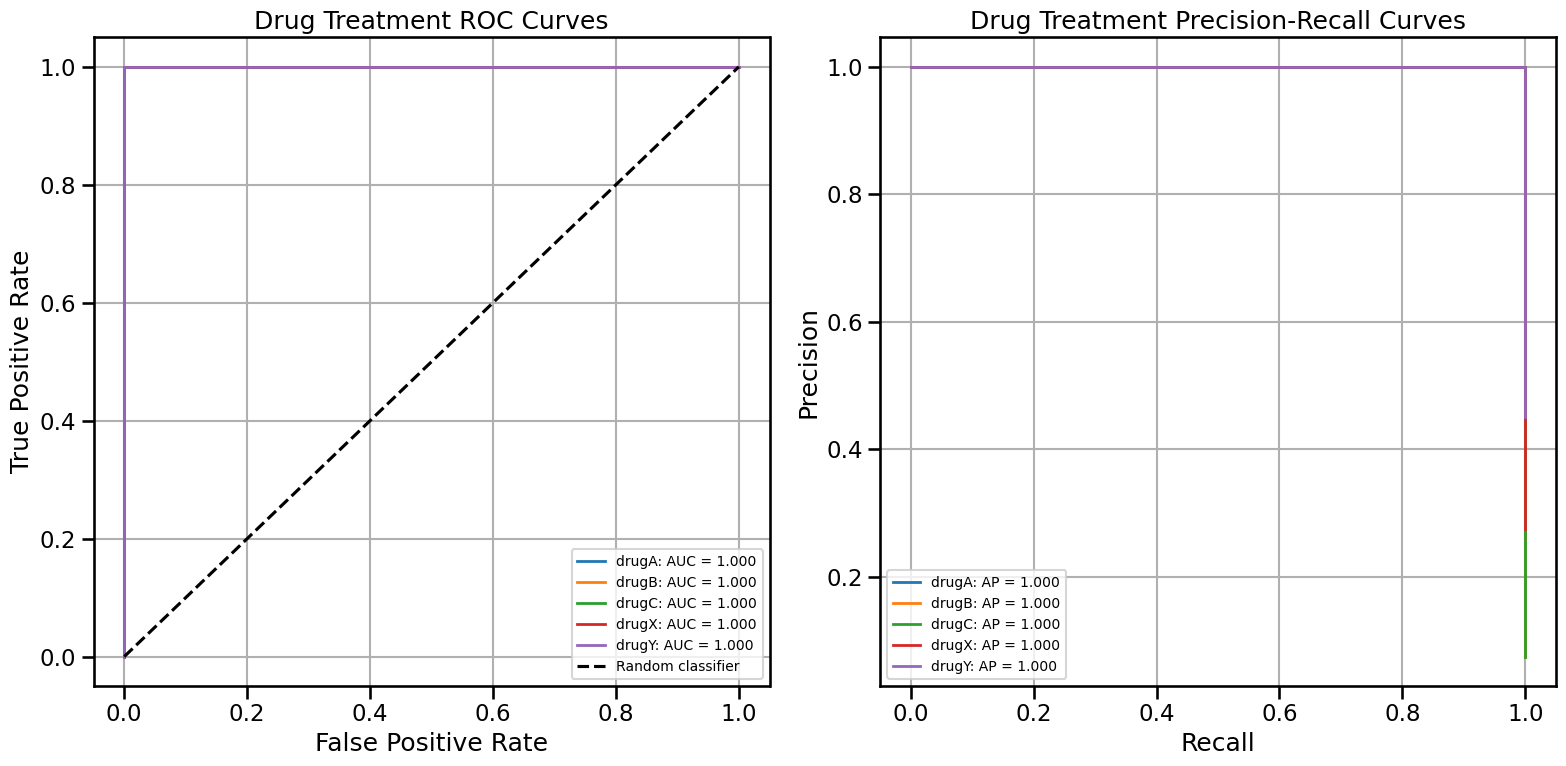

In [ ]:
classes = drug_rf.classes_
y_score = drug_rf.predict_proba(X_test)
y_test_binary = pd.get_dummies(pd.Categorical(y_test, categories=classes))

fig, axes = plt.subplots(ncols=2, figsize=(16, 8))

for i, class_name in enumerate(classes):
    # ROC curve
    fpr, tpr, _ = roc_curve(y_test_binary.iloc[:, i], y_score[:, i])
    roc_auc = roc_auc_score(y_test_binary.iloc[:, i], y_score[:, i])
    axes[0].plot(
        fpr, tpr, linewidth=2, label=f"{class_name}: AUC = {roc_auc:.3f}"
    )

    # Precision-recall curve
    precision, recall, _ = precision_recall_curve(
        y_test_binary.iloc[:, i], y_score[:, i]
    )
    avg_precision = metrics.average_precision_score(
        y_test_binary.iloc[:, i], y_score[:, i]
    )
    axes[1].plot(
        recall,
        precision,
        linewidth=2,
        label=f"{class_name}: AP = {avg_precision:.3f}",
    )

axes[0].plot(
    [0, 1], [0, 1], linestyle="--", color="black", label="Random classifier"
)
axes[0].set(
    title="Drug Treatment ROC Curves",
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
)
axes[0].legend(fontsize=10)
axes[0].grid(True)

axes[1].set(
    title="Drug Treatment Precision-Recall Curves",
    xlabel="Recall",
    ylabel="Precision",
)
axes[1].legend(fontsize=10)
axes[1].grid(True)

plt.tight_layout()
plt.show()

**Findings:**

The drug treatment model performs perfectly on this test split. The classification report shows precision, recall, and F1-score of `1.00` for all five drug classes. The confusion matrix and one-vs-rest curves should confirm that the model separates the drug classes very clearly on this test data.


#### **Feature Importance**

Plot the most important patient features used by the best Random Forest model.


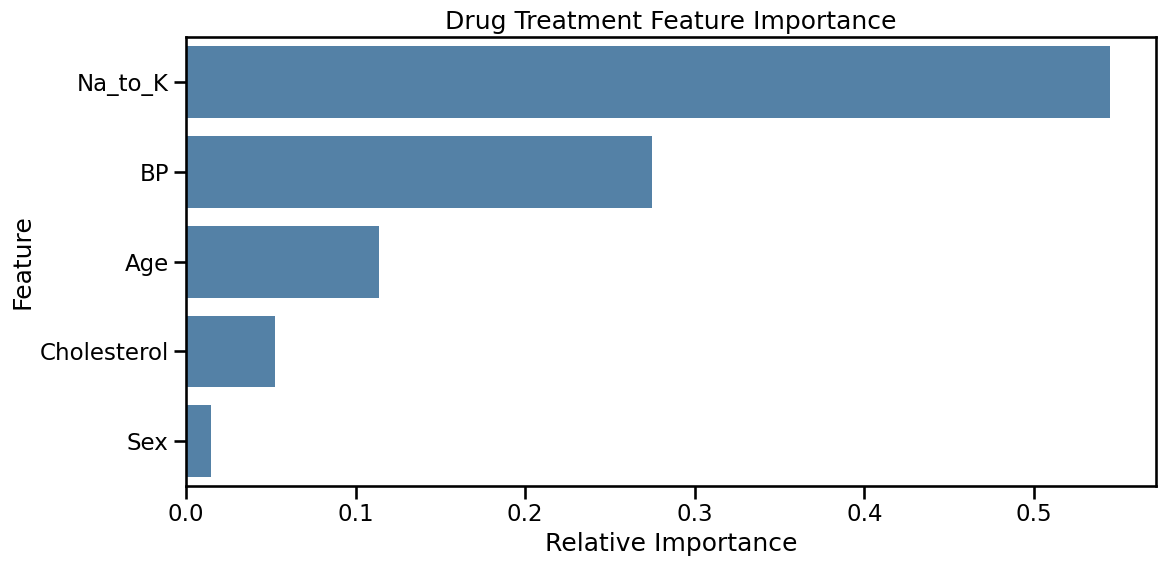

In [ ]:
feature_names = ["Age", "Sex", "BP", "Cholesterol", "Na_to_K"]

feature_imp = pd.Series(
    drug_rf.feature_importances_, index=feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(x=feature_imp.values, y=feature_imp.index, ax=ax, color="steelblue")
ax.set(
    title="Drug Treatment Feature Importance",
    xlabel="Relative Importance",
    ylabel="Feature",
)

plt.tight_layout()
plt.show()

**Findings:**

The feature-importance plot shows which patient characteristics are most useful for predicting the recommended drug. In this dataset, `Na_to_K` is usually the strongest predictor, while blood pressure, cholesterol, and age also help separate the drug classes. `Sex` usually contributes less than the other features.


## **Authors**

Su Wu